## Task 1: Environment Setup, Image I/O & Morphological Operations


### 1.1 Environment setup & image loading

In [1]:
!git clone https://github.com/Deepvejpara/CV_PR3_Deep_Learning.git -q

fatal: destination path 'CV_PR3_Deep_Learning' already exists and is not an empty directory.


In [2]:
import cv2, numpy as np, matplotlib.pyplot as plt, os

In [3]:
os.chdir('CV_PR3_Deep_Learning')

In [4]:
print(cv2.__version__)

5.0.0


In [5]:
img = cv2.imread('Images/dog.jpg')

In [6]:
img.shape

(3744, 2316, 3)

In [7]:
img.dtype

dtype('uint8')

In [8]:
rgb = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)

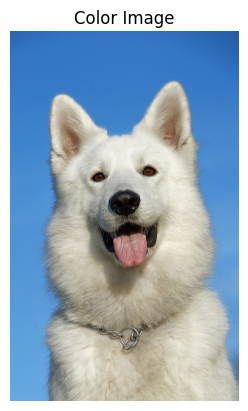

In [9]:
plt.imshow(rgb)
plt.axis("off")
plt.title('Color Image')
plt.show()

### 1.2 Binarize a test image

In [10]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

In [11]:
_,binary = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

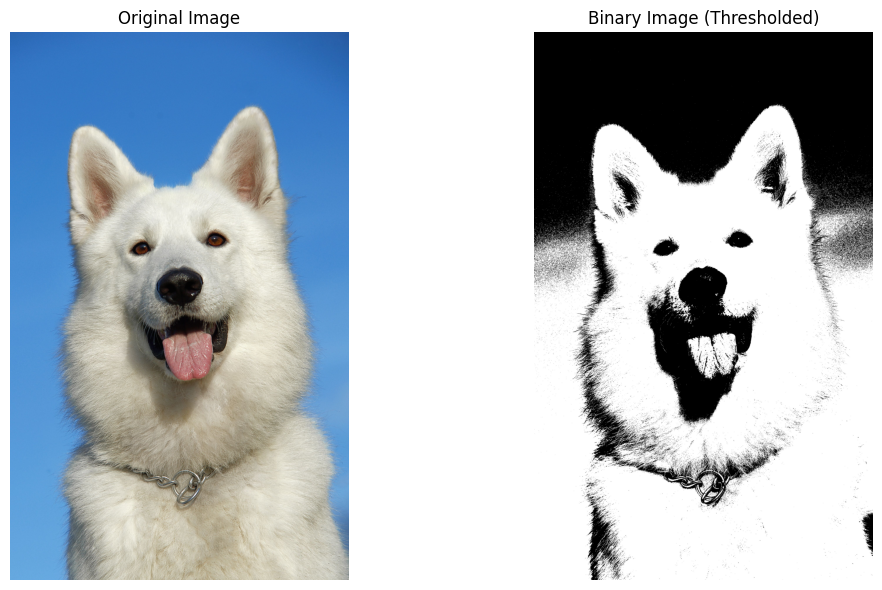

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(binary, cmap='gray')
axes[1].set_title('Binary Image (Thresholded)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

### 1.3 Apply the four morphological operations

In [13]:
kernel = np.ones((5,5), np.uint8)

In [14]:
erode = cv2.erode(binary,kernel,iterations=1)

In [15]:
dilate = cv2.dilate(binary,kernel,iterations=1)

In [16]:
opening = cv2.morphologyEx(
    binary,
    cv2.MORPH_OPEN,
    kernel
)

In [17]:
closing = cv2.morphologyEx(
    binary,
    cv2.MORPH_CLOSE,
    kernel
)

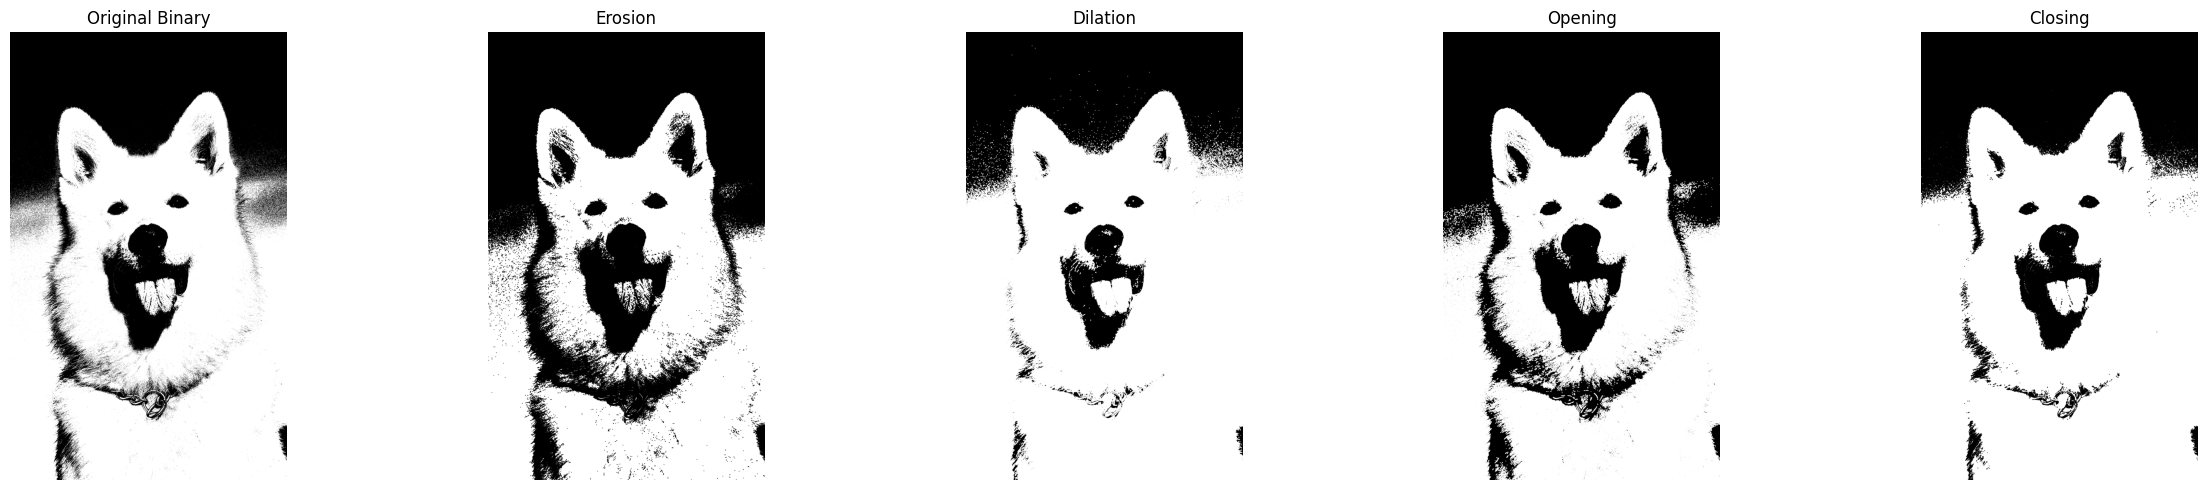

In [18]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

# Original Binary
axes[0].imshow(binary, cmap='gray')
axes[0].set_title('Original Binary')
axes[0].axis('off')

# Erosion
axes[1].imshow(erode, cmap='gray')
axes[1].set_title('Erosion')
axes[1].axis('off')

# Dilation
axes[2].imshow(dilate, cmap='gray')
axes[2].set_title('Dilation')
axes[2].axis('off')

# Opening
axes[3].imshow(opening, cmap='gray')
axes[3].set_title('Opening')
axes[3].axis('off')

# Closing
axes[4].imshow(closing, cmap='gray')
axes[4].set_title('Closing')
axes[4].axis('off')

plt.tight_layout()
plt.show()

### 1.4 Kernel shape & size comparison

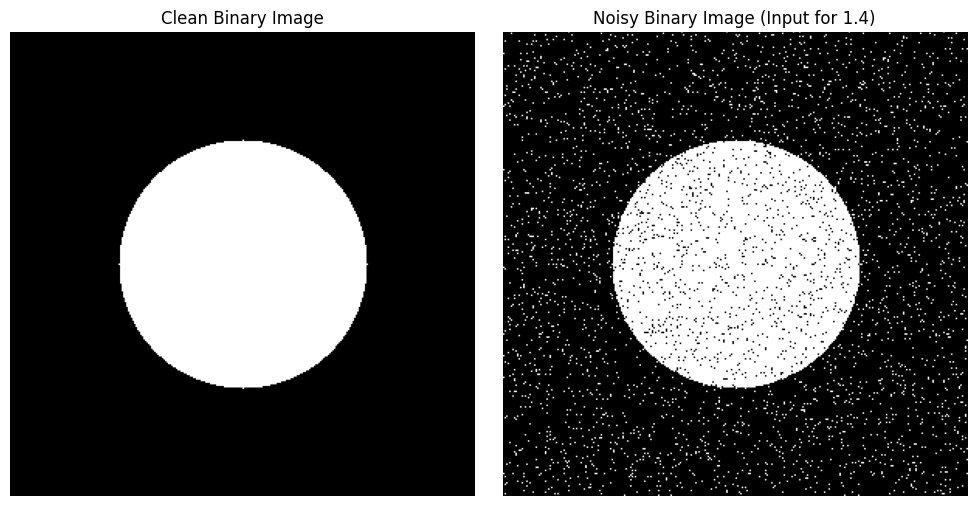

In [19]:
# 1. Create a blank black canvas
canvas = np.zeros((300, 300), dtype=np.uint8)

# 2. Draw a clean, solid white circle in the center
cv2.circle(canvas, (150, 150), 80, 255, -1)

# 3. Add Salt and Pepper Noise
noisy_img = canvas.copy()
# Generate a matrix of random integers from 0 to 100
noise_matrix = np.random.randint(0, 100, noisy_img.shape)

# Add "Salt" (white noise) where the random number is > 95 (5% of pixels)
noisy_img[noise_matrix > 95] = 255

# Add "Pepper" (black holes) where the random number is < 5 (5% of pixels)
noisy_img[noise_matrix < 5] = 0

# Plot the clean vs. noisy image
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

axes[0].imshow(canvas, cmap='gray')
axes[0].set_title('Clean Binary Image')
axes[0].axis('off')

axes[1].imshow(noisy_img, cmap='gray')
axes[1].set_title('Noisy Binary Image (Input for 1.4)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

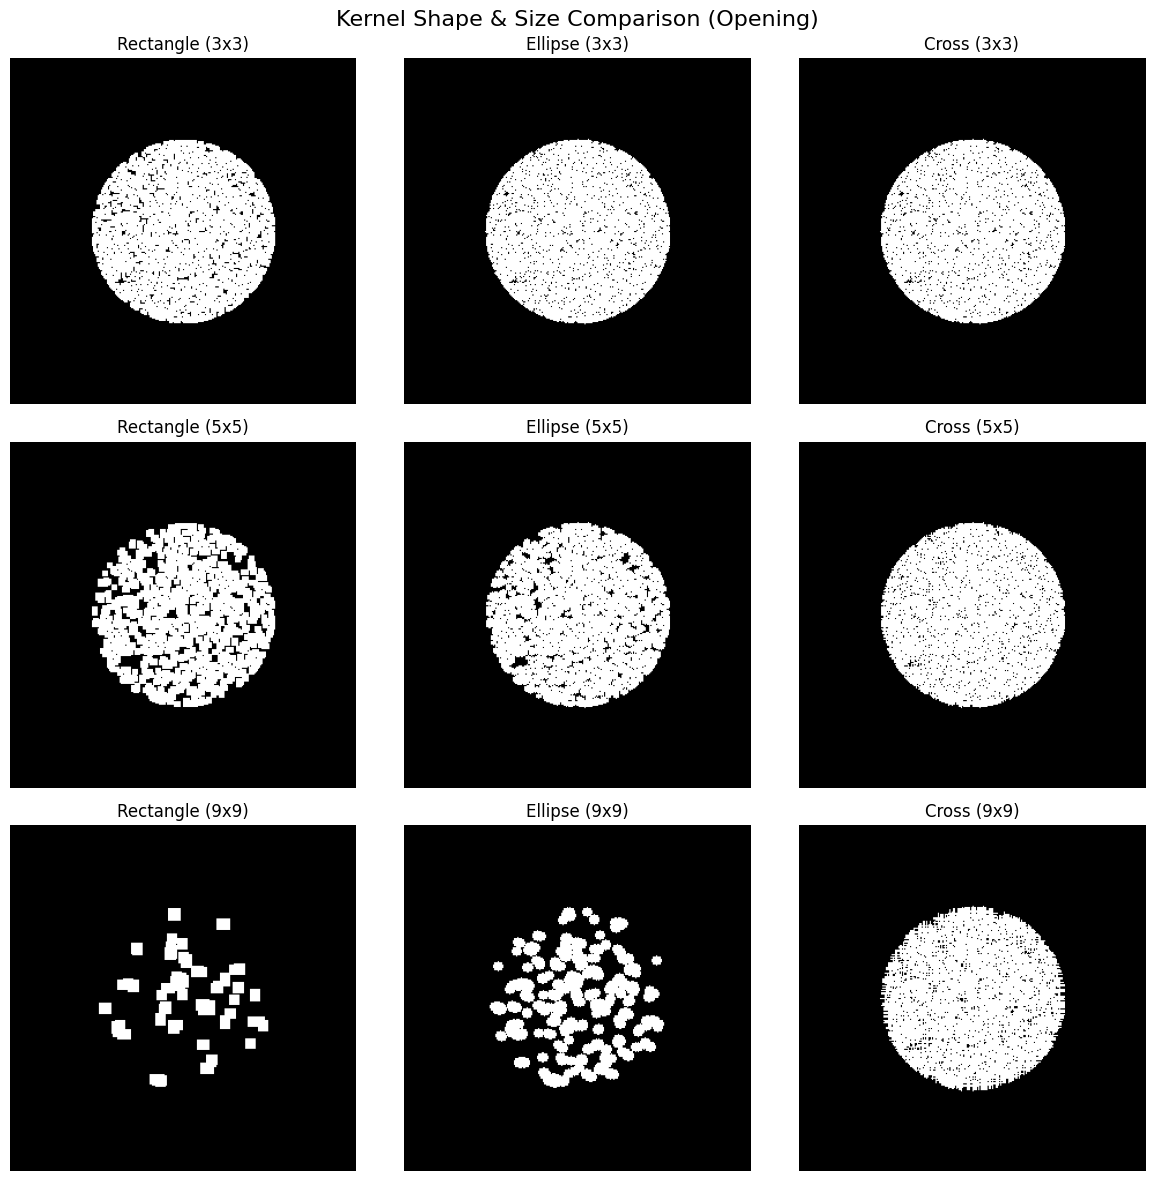

In [20]:
# Define the shapes and sizes required
shapes = [cv2.MORPH_RECT, cv2.MORPH_ELLIPSE, cv2.MORPH_CROSS]
shape_names = ['Rectangle', 'Ellipse', 'Cross']
sizes = [3, 5, 9]

# Create a 3x3 grid (3 sizes x 3 shapes)
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for i, size in enumerate(sizes):
    for j, shape in enumerate(shapes):
        kernel = cv2.getStructuringElement(shape, (size, size))

        result = cv2.morphologyEx(noisy_img, cv2.MORPH_OPEN, kernel)

        # Plot the result
        axes[i, j].imshow(result, cmap='gray')
        axes[i, j].set_title(f'{shape_names[j]} ({size}x{size})')
        axes[i, j].axis('off')

plt.suptitle('Kernel Shape & Size Comparison (Opening)', fontsize=16)
plt.tight_layout()
plt.show()

### 1.5 WHY morphology works

* **Erosion:** Acts as a local minimum filter that shrinks white regions and removes small bright noise[cite: 1].
  * **Real-world scenario:** Removing tiny bright sensor artifacts or stray background reflections from a low-light surveillance feed before passing the mask to a downstream YOLO detector, preventing false positive detections.

* **Dilation:** Acts as a local maximum filter that grows white regions and fills small dark gaps[cite: 1].
  * **Real-world scenario:** Reconnecting fragmented parts of a single object's mask (e.g., a pedestrian partially obscured by a thin fence) so the detector evaluates it as one cohesive entity.

* **Opening:** The process of erosion followed by dilation; it removes small noise while preserving the overall shape and size of the target object[cite: 1].
  * **Real-world scenario:** Cleaning up "salt" noise (stray bright pixels) in a retail analytics camera without shrinking the actual bounding boxes of the products or customers you want to detect.

* **Closing:** The process of dilation followed by erosion; it fills small holes without shrinking the main object[cite: 1].
  * **Real-world scenario:** Filling in "pepper" noise or dark glare spots inside a masked object (like a solid-colored vehicle), ensuring the downstream object detector receives a solid, continuous shape rather than a fragmented one.

## Task 2: Bitwise Operations & Image Histograms

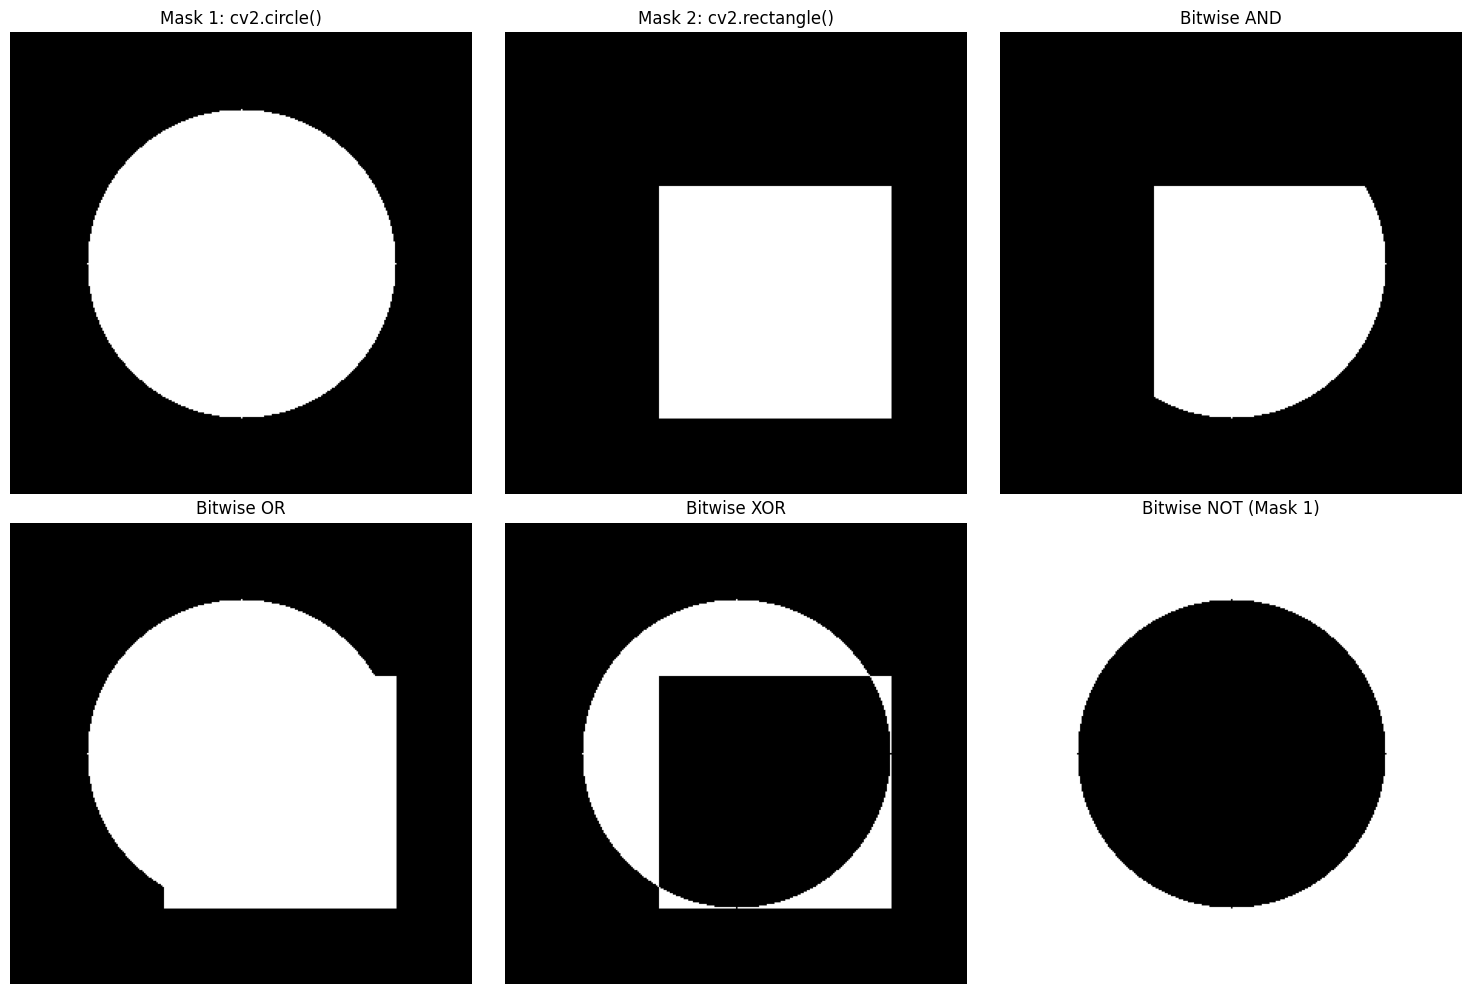

In [21]:
# 1. Create two blank canvases using np.zeros
# Both must be the same size and type (uint8)
canvas_size = (300, 300)
mask1 = np.zeros(canvas_size, dtype=np.uint8)
mask2 = np.zeros(canvas_size, dtype=np.uint8)

# 2. Draw shapes to create binary masks
# Mask 1: A solid white circle in the center
cv2.circle(mask1, (150, 150), 100, 255, -1)

# Mask 2: A solid white rectangle offset to the bottom right
cv2.rectangle(mask2, (100, 100), (250, 250), 255, -1)

# 3. Apply the four bitwise operations
bit_and = cv2.bitwise_and(mask1, mask2)
bit_or  = cv2.bitwise_or(mask1, mask2)
bit_xor = cv2.bitwise_xor(mask1, mask2)
bit_not = cv2.bitwise_not(mask1) # NOT is unary, applied to mask1

# 4. Plot a 2x3 grid: two source masks + four results
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Top row: Source masks and AND
axes[0, 0].imshow(mask1, cmap='gray')
axes[0, 0].set_title('Mask 1: cv2.circle()')

axes[0, 1].imshow(mask2, cmap='gray')
axes[0, 1].set_title('Mask 2: cv2.rectangle()')

axes[0, 2].imshow(bit_and, cmap='gray')
axes[0, 2].set_title('Bitwise AND')

# Bottom row: OR, XOR, NOT
axes[1, 0].imshow(bit_or, cmap='gray')
axes[1, 0].set_title('Bitwise OR')

axes[1, 1].imshow(bit_xor, cmap='gray')
axes[1, 1].set_title('Bitwise XOR')

axes[1, 2].imshow(bit_not, cmap='gray')
axes[1, 2].set_title('Bitwise NOT (Mask 1)')

# Hide axes ticks for cleaner presentation
for ax in axes.flat:
    ax.axis('off')

plt.tight_layout()
plt.show()

### 2.2 Applied use-case: masked overlay

In [22]:
# 1. Load a real photo
img_bgr = cv2.imread('images/mountain.jpg')
# Resize for consistency in this example
img_bgr = cv2.resize(img_bgr, (400, 400))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# --- Part A: Extract masked region using bitwise_and ---
# Create a circular ROI mask (single channel, same width/height as image)
mask = np.zeros(img_rgb.shape[:2], dtype=np.uint8)
cv2.circle(mask, (200, 200), 120, 255, -1)

# Extract the region: AND the image with itself, applying the mask
extracted_roi = cv2.bitwise_and(img_rgb, img_rgb, mask=mask)

# --- Part B: Composite a logo/watermark using bitwise_or ---
# Create a blank black image for the watermark (must match image shape)
watermark = np.zeros_like(img_rgb)
# Draw text to act as our "logo" (white text)
cv2.putText(watermark, 'CONFIDENTIAL', (50, 350),
            cv2.FONT_HERSHEY_SIMPLEX, 1.2, (255, 255, 255), 3)

# Composite the watermark onto the extracted ROI using OR
# White pixels in the watermark will overwrite the background
composited_img = cv2.bitwise_or(img_rgb, watermark)

# --- Visualization: Before and After ---
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Top row: ROI Extraction
axes[0, 0].imshow(img_rgb)
axes[0, 0].set_title('Original Photo (Before)')
axes[0, 1].imshow(extracted_roi)
axes[0, 1].set_title('Extracted Circular ROI (bitwise_and)')

# Bottom row: Watermark Composite
axes[1, 0].imshow(watermark)
axes[1, 0].set_title('Watermark Logo')
axes[1, 1].imshow(composited_img)
axes[1, 1].set_title('Composited Image (bitwise_or)')

for ax in axes.flat:
    ax.axis('off')

plt.tight_layout()
plt.show()

error: OpenCV(5.0.0) /io/opencv/modules/imgproc/src/resize.cpp:4217: error: (-215:Assertion failed) !ssize.empty() in function 'resize'
